<a href="https://colab.research.google.com/github/Beatrizkrf/Aulas_PA/blob/main/Wine_Quality_Dataset_(Avalia%C3%A7%C3%A3o_de_vinhos).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Dataset (Avaliação de vinhos)

In [25]:
# IMPORTAÇÃO DE BIBLIOTECAS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **1. Definição do Problema:**
Qual a questão a ser resolvida? O que esperamos descobrir com a análise?

  1. Existe alguma correlação entre o teor de cloretos e a qualidade do vinho?
  2. Qual é a relação estatística entre os níveis de dióxido de enxofre e sulfatos?
  3. Como os níveis de acidez fixa e volátil se relacionam com a qualidade do vinho?


# Significados das colunas:

- Acidez Fixa: Medea acidez do vinho.
- Acidez Volátil: Indica a presença de ácidos orgânicos voláteis, como ácido acético, que pode indicar deterioração.
- Ácido Cítrico: Representa o teor de ácido não volátil, contribuindo para o frescor do vinho.
- Açúcar Residual: A quantidade de açúcar restante após a fermentação.
- Cloretos: Mede o teor de sal no vinho.
- Dióxido de Enxofre Livre: A quantidade de dióxido de enxofre livre, um agente antimicrobiano.
- Dióxido de Enxofre Total: A quantidade total de dióxido de enxofre livre e ligado.
- Densidade: A densidade do vinho, influenciada pelos níveis de álcool e açúcar.
 pH: O nível de acidez ou alcalinidade do vinho.
- Sulfatos: A quantidade de sulfatos, que contribuem para os níveis de gás dióxido de enxofre.
- Álcool: A porcentagem de álcool presente no vinho.
- Qualidade: (pontuação entre 0 e 10)

# **2 - Coleta de Dados:**

In [26]:
# CARREGAR OS DADOS
df = pd.read_csv("https://raw.githubusercontent.com/Beatrizkrf/Aulas_PA/refs/heads/main/winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# **3 - Exploração de Dados:**

In [5]:
# Verificando valores faltantes
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [6]:
# Exibindo informações gerais dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
# Estatísticas descritivas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# 4 - **Limpeza de Dados**

In [8]:
# removendo as duplicatas
total_duplicatas = df.duplicated().sum()
print(f"Total de duplicatas encontradas: {total_duplicatas}")

df = df.drop_duplicates()

print(f"Total de duplicatas após a remoção: {df.duplicated().sum()}")

Total de duplicatas encontradas: 240
Total de duplicatas após a remoção: 0


# **5 - Vizualizção de Dados**

In [11]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


 1. Existe alguma correlação entre o teor de cloretos e a qualidade do vinho?

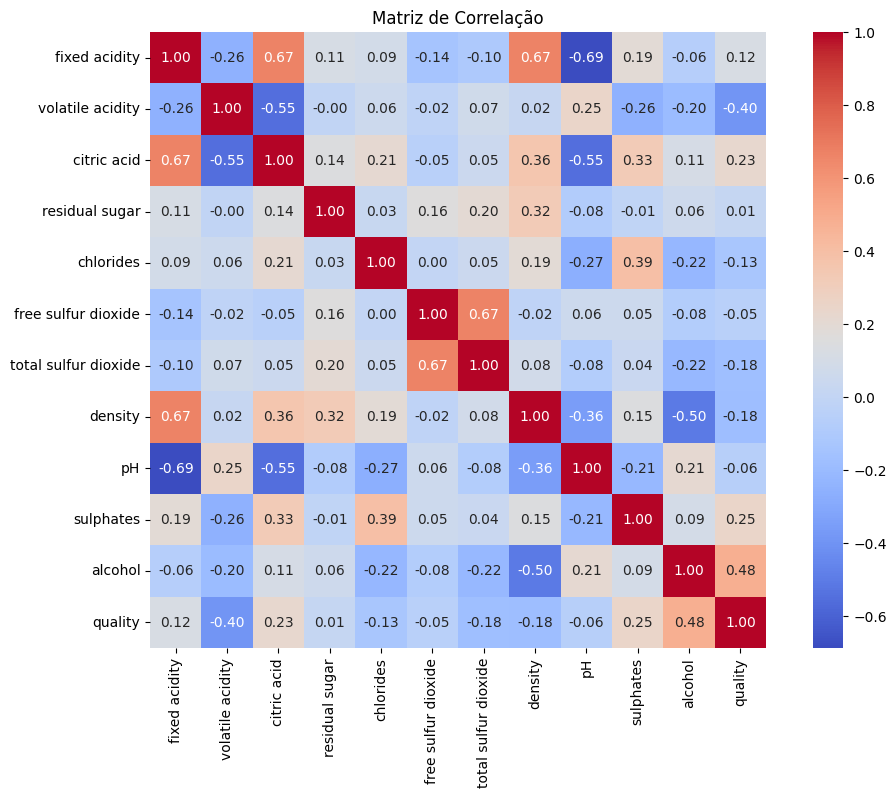

In [12]:
#grafico de correlação geral
correlation_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlação')
plt.show()

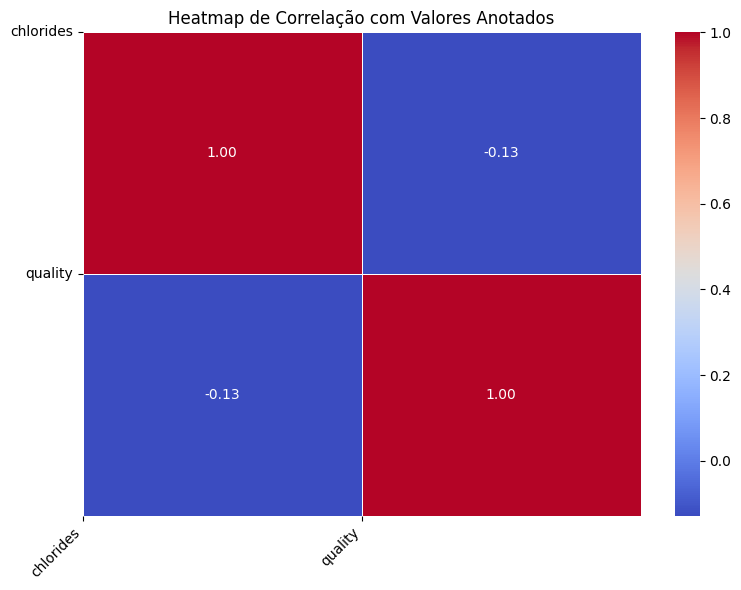

In [28]:
#correlação do teor de cloretos e a qualidade
cols = ['chlorides','quality']
plot_data = df[cols]

corr = plot_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

plt.xticks(range(len(plot_data.columns)), plot_data.columns, rotation=45, ha='right')
plt.yticks(range(len(plot_data.columns)), plot_data.columns, rotation=0)
plt.title('Heatmap de Correlação com Valores Anotados')
plt.tight_layout()

plt.show()


Resposta: Existe forte relação negativa entre o teor de cloretos e a qualidade pois o cloreto não é o fator mais importante para decidir a qualidade.

2 - Qual é a relação entre os níveis de dióxido de enxofre e sulfatos?

In [29]:
#gráfico de dispersão

#plt.figure(figsize=(10, 6))
#plt.scatter(df['free sulfur dioxide'], df['sulphates'], color='blue', marker='o')
#plt.title('Relação entre Dióxido de Enxofre Livre e Sulfatos')
#plt.xlabel('Níveis de Dióxido de Enxofre Livre (mg/L)')
#plt.ylabel('Níveis de Sulfatos (g/L)')
#plt.grid(True)
#plt.axhline(0, color='black', linewidth=0.5, ls='--')
#plt.axvline(0, color='black', linewidth=0.5, ls='--')
#plt.show()

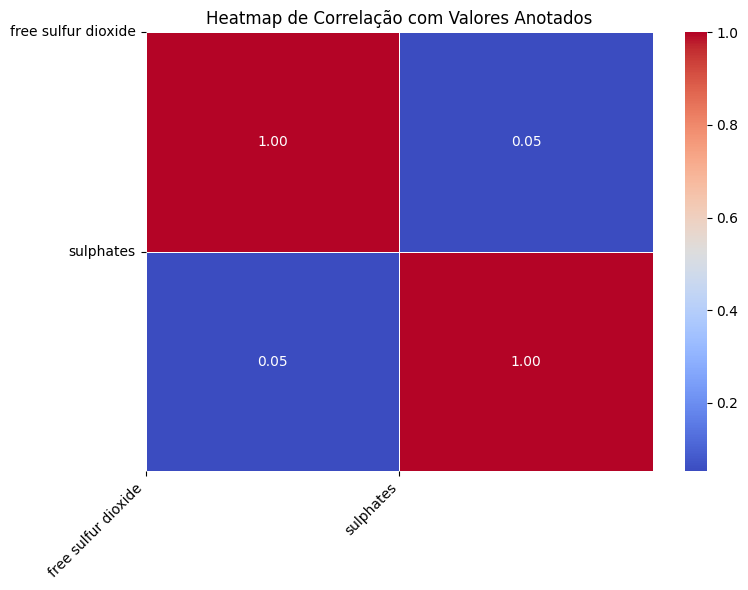

In [30]:
# gráfico de calor
cols = ['free sulfur dioxide','sulphates']
plot_data = df[cols]

corr = plot_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

plt.xticks(range(len(plot_data.columns)), plot_data.columns, rotation=45, ha='right')
plt.yticks(range(len(plot_data.columns)), plot_data.columns, rotation=0)
plt.title('Heatmap de Correlação com Valores Anotados')
plt.tight_layout()

plt.show()

Resposta:
O gráfico de calor indica que não existe correlação direta entre o dióxido de enxofre livre e os níveis de enxofre nos vinhos analisados. Isto significa que um aumento ou diminuição num destes compostos não está correlacionado com uma alteração no outro composto.


3- Como os níveis de acidez fixa e volátil se relacionam com a qualidade do vinho?

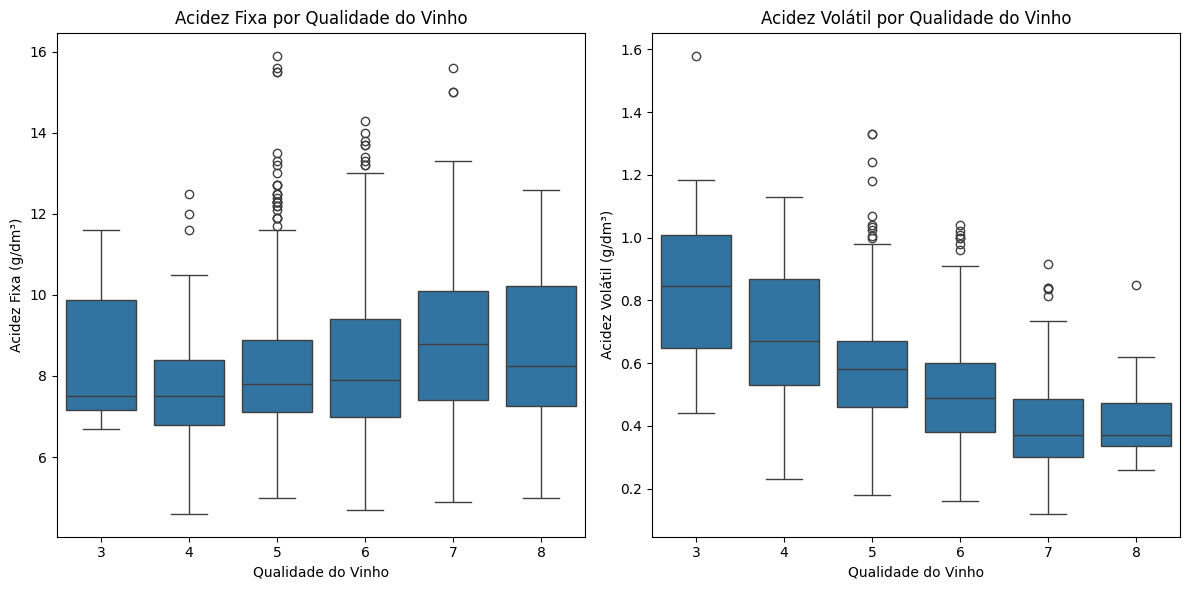

In [31]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # (linhas, colunas, índice)
sns.boxplot(x='quality', y='fixed acidity', data=df)
plt.title('Acidez Fixa por Qualidade do Vinho')
plt.xlabel('Qualidade do Vinho')
plt.ylabel('Acidez Fixa (g/dm³)')

# Criação do gráfico de box plot para acidez volátil
plt.subplot(1, 2, 2)
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Acidez Volátil por Qualidade do Vinho')
plt.xlabel('Qualidade do Vinho')
plt.ylabel('Acidez Volátil (g/dm³)')

plt.tight_layout()
plt.show()

Resposta: A acidez é importante, mas não é a única coisa que determina se um vinho é bom ou ruim, precisa estar na quantidade certa para que fique saboroso.